# Correcting the correction

So far we've verified the new `get_curves()` and `correct_sf()` functions successfully reproduce the best figure from the ApJ paper. They do! Just need to multiply the SFs by 3 as previously they were a sum, not an average.

In [1]:
import glob
import os
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

from scipy.interpolate import interp1d
sys.path.append(os.path.abspath(".."))
import src.params as params
import src.sf_funcs as sf
import src.utils as utils  # copied directly from Reynolds project, normalize() added

times_to_gap = params.times_to_gap
pwrl_range = params.pwrl_range
data_path_prefix = params.data_path_prefix
run_mode = params.run_mode

spacecraft = "wind"
n_bins = 25

#### Reading full results file for Wind results in paper

In [2]:
path =  "../results/full/test_sfs_corrected_subset/wi_h2_mfi_20160627_v05_corrected_25_bins_with_sfs.pkl"
input_file_list = [path]
all_files_metadata = []
all_ints_metadata = []
all_ints = []
all_ints_gapped_metadata = []
all_ints_gapped = []
all_sfs = []
all_sfs_gapped_corrected = []

for file in input_file_list:
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
    except pickle.UnpicklingError:
        print(f"UnpicklingError encountered in file: {file}.")
        continue
    except EOFError:
        print(f"EOFError encountered in file: {file}.")
        continue
    except Exception as e:
        print(f"An unexpected error {e} occurred with file: {file}.")
        continue
    print(f"Loaded {file}")

    # Unpack the dictionary and append to lists
    all_files_metadata.append(data["files_metadata"])
    all_ints_metadata.append(data["ints_metadata"])
    all_ints.append(data["ints"])
    all_ints_gapped_metadata.append(data["ints_gapped_metadata"])
    all_ints_gapped.append(data["ints_gapped"])
    all_sfs.append(data["sfs"])
    all_sfs_gapped_corrected.append(data["sfs_gapped_corrected"])

# Concatenate all dataframes
files_metadata = pd.concat(all_files_metadata, ignore_index=True)
ints_metadata = pd.concat(all_ints_metadata, ignore_index=True)
ints_gapped_metadata = pd.concat(all_ints_gapped_metadata, ignore_index=True)
ints_gapped = pd.concat(all_ints_gapped, ignore_index=True)
sfs = pd.concat(all_sfs, ignore_index=True)
sfs_gapped_corrected = pd.concat(all_sfs_gapped_corrected, ignore_index=True)

# Flatten the list of lists for ints
ints = [item for sublist in all_ints for item in sublist]

index = 0

print(
    f"Successfully read in {input_file_list[index]}. This contains {len(ints_metadata)}x{times_to_gap} intervals"
)

# Parameters for the case study plots

file_index = files_metadata["file_index"].values[0]
# THERE IS NOW JUST ONE FILE INDEX TO WORRY ABOUT
# (so could really remove this indexing from code below)

int_index = 1  # Selecting first (possibly only) interval from this file

print(
    "Currently making plots for file index",
    file_index,
    "and interval",
    int_index,
)

# Importing lookup table
with open(
    f"../results/{run_mode}/correction_lookup_3d_{n_bins}_bins_lint.pkl", "rb"
) as f:
    correction_lookup_3d = pickle.load(f)

Loaded ../results/full/test_sfs_corrected_subset/wi_h2_mfi_20160627_v05_corrected_25_bins_with_sfs.pkl
Successfully read in ../results/full/test_sfs_corrected_subset/wi_h2_mfi_20160627_v05_corrected_25_bins_with_sfs.pkl. This contains 3x25 intervals
Currently making plots for file index 81 and interval 1


In [3]:
data_path_prefix = params.data_path_prefix
run_mode = params.run_mode
pwrl_range = params.pwrl_range
palette = params.gap_handling_palette

file_index, version, local_int_index, int_index = (81, 10, 0, 0)

In [4]:
def compute_scaling(sf_df, correction_lookup, n_bins=25):
    """Compute scaling factors for a structure-function DataFrame using a lookup.

    Parameters
    - sf_df: pandas.DataFrame with columns ['lag', 'gp', 'sf']
    - correction_lookup: dict-like lookup with keys 'xedges','yedges','zedges',
        'scaling', 'scaling_lower', 'scaling_upper'
    - n_bins: number of bins per axis in the lookup (default: 25)

    Returns
    - DataFrame: copy of `sf_df` with columns 'scaling','scaling_lower','scaling_upper'
    """

    # Validate correction_lookup structure
    required_keys = [
        "xedges",
        "yedges",
        "zedges",
        "scaling",
        "scaling_lower",
        "scaling_upper",
    ]

    for key in required_keys:
        if key not in correction_lookup:
            raise ValueError(f"Missing required key: {key}")

    # Extract bins and scaling factors from the lookup table
    xedges = correction_lookup["xedges"]
    yedges = correction_lookup["yedges"]
    zedges = correction_lookup["zedges"]
    scaling = correction_lookup["scaling"]
    scaling_lower = correction_lookup["scaling_lower"]
    scaling_upper = correction_lookup["scaling_upper"]

    # Compute bin indices for the interpolated SF
    x = sf_df["lag"].values
    y = sf_df["gp"].values
    z = sf_df["sf"].values
    xidx = np.clip(np.digitize(x, xedges) - 1, 0, n_bins - 1)
    yidx = np.clip(np.digitize(y, yedges) - 1, 0, n_bins - 1)
    zidx = np.clip(np.digitize(z, zedges) - 1, 0, n_bins - 1)

    # Initialize result DataFrame
    result = sf_df.copy()

    result["scaling"] = scaling[xidx, yidx, zidx]
    result["scaling_lower"] = scaling_lower[xidx, yidx, zidx]
    result["scaling_upper"] = scaling_upper[xidx, yidx, zidx]

    return result


# Smoothing function
def smooth_scaling(x, y, num_bins=20):
    # Ensure numpy arrays for indexing and math
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    if x_arr.size == 0:
        return y_arr

    # Guard against non-positive or constant x
    x_min = x_arr.min()
    x_max = x_arr.max()
    if x_min <= 0 or x_max <= 0 or x_min == x_max:
        # Fall back to a simple smoothing (moving average) when logspace isn't possible
        kernel = np.ones(3) / 3.0
        y_pad = np.pad(y_arr, (1, 1), mode="edge")
        y_smooth = np.convolve(y_pad, kernel, mode="valid")
        return y_smooth

    bin_edges = np.logspace(np.log10(x_min), np.log10(x_max), num_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    y_binned = []
    for i in range(len(bin_edges) - 1):
        mask = (x_arr >= bin_edges[i]) & (x_arr < bin_edges[i + 1])
        if np.any(mask):
            y_binned.append(np.nanmean(y_arr[mask]))
        else:
            y_binned.append(np.nan)
    y_binned = np.array(y_binned)

    # Build full arrays including edges for interpolation
    full_bins = np.concatenate(([bin_edges[0]], bin_centers, [bin_edges[-1]]))
    # Use first/last non-nan values as edge values
    if np.all(np.isnan(y_binned)):
        full_y_binned = np.ones_like(full_bins)
    else:
        first = y_binned[~np.isnan(y_binned)][0]
        last = y_binned[~np.isnan(y_binned)][-1]
        full_y_binned = np.concatenate(([first], y_binned, [last]))

    # Replace any remaining nans
    full_y_binned = np.nan_to_num(full_y_binned, nan=1.0)

    interp_func = interp1d(
        full_bins, full_y_binned, kind="cubic", fill_value="extrapolate"
    )
    return interp_func(x_arr)



In [5]:
def correct_sf(interval, correction_lookup):
    """
    Correct the structure function using the correction lookup table.
    Also smooth the scaling function prior to applying the correction.
    This is done to avoid discontinuities in the correction factor.

    Parameters
    - interval: metadata dict for the interval (must have gap_status 'corrected')
    - correction_lookup: lookup dict used by `compute_scaling`

    Returns
    - tuple: (corrected_sf, corrected_sf_lower, corrected_sf_upper) as numpy arrays
    """

    if interval["gap_status"] != "corrected":
        raise ValueError(
            "This function is only for correcting structure functions with gap_status 'corrected'."
        )

    sf_df = pd.DataFrame(
        {
            "lag": interval["lag"],
            "sf": interval["sf"],
            "gp": interval["gp"],
        }
    )

    # Merge the SF with the correction lookup table
    sf_df_scaled = compute_scaling(
        sf_df,
        correction_lookup,
    )

    scaling_smooth = smooth_scaling(sf_df_scaled.lag, sf_df_scaled.scaling)
    scaling_smooth_lower = smooth_scaling(sf_df_scaled.lag, sf_df_scaled.scaling_lower)
    scaling_smooth_upper = smooth_scaling(sf_df_scaled.lag, sf_df_scaled.scaling_upper)

    # Apply the correction factor to the SF
    corrected_sf = sf_df_scaled.sf * scaling_smooth
    corrected_sf_lower = sf_df_scaled.sf * scaling_smooth_lower
    corrected_sf_upper = sf_df_scaled.sf * scaling_smooth_upper

    return corrected_sf.values, corrected_sf_lower.values, corrected_sf_upper.values

In [6]:
def compute_sf(
    data,
    lags,
    powers=[2],
    retain_increments=False,
    alt_estimators=True,
    pwrl_range=None,
):
    """
    Routine to compute the increments of a time series and then the mean (structure function) and standard deviation
    of the PDF of these increments, raised to the specified powers.
    Input:
            data: pd.DataFrame of data to be analysed. Must have shape (1, N) or (3, N)
            lags: The array consisting of lags, being the number of points to shift each of the series
            powers: The array consisting of the Structure orders to perform on the series for all lags
    Output:
            df: The DataFrame containing  corresponding to lags for each order in powers
    """
    # run through lags and powers so that for each power, run through each lag
    df = {}

    if data.shape[1] == 1:
        ax = data.iloc[:, 0].copy()
        for i in powers:
            array = []
            mean_array = []
            mapd_array = []
            std_array = []
            N_array = []
            for lag in lags:
                lag = int(lag)
                dax = ax.shift(-lag) - ax
                strct = dax.pow(i)

                array += [strct.values]
                strct_mean = strct.mean()
                if dax.isnull().sum() != len(dax):
                    # Otherwise this func will raise an error
                    median_abs_diff = np.nanmedian(dax)
                else:
                    median_abs_diff = np.nan
                mean_array += [strct_mean]
                mapd_array += [median_abs_diff]
                strct_std = strct.std()
                std_array += [strct_std]

                N = dax.notnull().sum()
                N_array += [N]

                df["lag"] = lags
                df["n"] = N_array
                df["sf_" + str(i)] = mean_array
                df["sf_" + str(i) + "_se"] = np.array(std_array) / np.sqrt(N_array)
                if retain_increments is True:
                    df["diffs_" + str(i)] = array
                    df["diffs_" + str(i) + "_sd"] = std_array

    elif data.shape[1] == 3:
        ax = data.iloc[:, 0].copy()
        ay = data.iloc[:, 1].copy()
        az = data.iloc[:, 2].copy()
        for i in powers:
            array = []
            mean_array = []
            mapd_array = []
            std_array = []
            N_array = []
            for lag in lags:
                lag = int(lag)
                dax = np.abs(ax.shift(-lag) - ax)
                day = np.abs(ay.shift(-lag) - ay)
                daz = np.abs(az.shift(-lag) - az)
                strct = (dax**2 + day**2 + daz**2).pow(0.5).pow(i)

                array += [strct.values]
                strct_mean = strct.mean()
                if strct.isnull().sum() != len(strct):
                    # Otherwise this func will raise an error
                    median_abs_diff = np.nanmedian(strct)
                else:
                    median_abs_diff = np.nan
                mean_array += [strct_mean]
                mapd_array += [median_abs_diff]
                strct_std = strct.std()
                std_array += [strct_std]

                N = dax.notnull().sum()
                N_array += [N]

                df["lag"] = lags
                df["n"] = N_array
                df["sf_" + str(i)] = mean_array
                df["sf_" + str(i) + "_se"] = np.array(std_array) / np.sqrt(N_array)
                if retain_increments is True:
                    df["diffs_" + str(i)] = array
                    df["diffs_" + str(i) + "_sd"] = std_array

    else:
        raise ValueError("Data is not in the shape (1, N) or (3, N)")

    df = pd.DataFrame(df, index=lags)
    if alt_estimators is True:
        df["mapd"] = mapd_array
        df["sf_2_ch"] = df["sf_0.5"] ** 4 / (0.457 + (0.494 / df["n"]))
        df["sf_2_dowd"] = (df["mapd"] ** 2) * 2.198
    # calculate sample size as a proportion of the maximum sample size (for that lag)
    df.insert(2, "gp", 100 * (1 - (df["n"] / (len(ax) - df.index))))

    if pwrl_range is not None:
        # Fit a line to the log-log plot of the structure function over the given range
        min, max = pwrl_range[0], pwrl_range[1]

        slope = np.polyfit(
            np.log(df.loc[min:max, "lag"]),
            np.log(df.loc[min:max, "sf_2"]),
            1,
        )[0]

        return df, slope

    else:
        return df

In [7]:
def get_curves(data, cadence):
    """Compute vector statistics (SF, PSD, ACF) for one interval.

    Parameters
    - data: pandas.DataFrame time-series for the interval
    - cadence: pandas-compatible frequency string (e.g. '1s')

    Returns
    - dict of vectors/arrays: 'sf','lag','lag_n','gp','acf','psd','psd_smooth','freq'
    """

    data_min_res = data

    lags = np.arange(1, params.max_lag_prop * len(data_min_res))
    powers = [2]

    # Get cadence in seconds
    cadence_s = pd.Timedelta(cadence).total_seconds()

    all_sfs = []
    for col in data.columns:

        print(f"Computing curves for {col}...")

        data_comp = data_min_res[col]
        col_sd = data_comp.std()
        col_mean = data_comp.mean()

        data_comp_std = (data_comp - col_mean) / col_sd

        # Compute the structure function
        sf_df = compute_sf(
            pd.DataFrame(data_comp_std), lags, powers, False, False, None
        )

        # if correction:
        # Perform the correction to sf_df here!

        # NOT UN-NORMALISING YET!
        sf_df["sf_2"] *= col_sd**2

        all_sfs.append(sf_df["sf_2"].values)

    sf = np.sum(all_sfs, axis=0) / 3

    # haar_sf = compute_haar()

    # equiv_spectrum = "Mark's code"

    # Prepare row
    vector_results = {
        "sf": sf,
        "sf_comps": all_sfs,
        "lag": lags,
        "lag_n": sf_df["n"].values,
        # Above are simply taken from most recent component SF; fine as all will be the same
        "gp": sf_df["gp"].values,
    }

    # Convert to DataFrame
    return vector_results



In [8]:
interval = ints[local_int_index]
int_gapped = ints_gapped.loc[
    (ints_gapped["file_index"] == file_index)
    & (ints_gapped["int_index"] == int_index)
    & (ints_gapped["version"] == version)
    & (ints_gapped["gap_handling"] == "naive"),
    ["time", "Bx", "By", "Bz"],  # Just plotting one component for simplicity
]
int_gapped.set_index("time", inplace=True)
print(
    f"{int_gapped.isna().sum()/len(int_gapped) * 100}% missing"
)
int_lint = int_gapped.interpolate(method="linear", limit_direction="both")
print(
    f"{int_lint.isna().sum()/len(int_lint) * 100} missing"
)

Bx    84.99
By    84.99
Bz    84.99
dtype: float64% missing
Bx    0.0
By    0.0
Bz    0.0
dtype: float64 missing


In [9]:
print(interval.mean())
print(interval.std())

Bx    1.194306
By   -0.847239
Bz    0.031909
dtype: float32
Bx    1.0
By    1.0
Bz    1.0
dtype: float32


Interestingly, stds are good, but means aren't all 0...

This computation takes about one minute

In [10]:
sf_true_new = get_curves(interval, "48s") 
sf_naive_new = get_curves(int_gapped, "48s")
sf_lint_new = get_curves(int_lint, "48s")

Computing curves for Bx...
Computing curves for By...
Computing curves for Bz...
Computing curves for Bx...
Computing curves for By...
Computing curves for Bz...
Computing curves for Bx...
Computing curves for By...
Computing curves for Bz...


In [11]:
sf_corrected_new = {
    "lag": sf_lint_new["lag"],
    "sf": sf_lint_new["sf"]*3,
    "gp": sf_naive_new["gp"],
    "gap_status": "corrected",
}

In [12]:
sf_corr_new, sf_corr_lower, sf_corr_upper = correct_sf(
    sf_corrected_new,
    correction_lookup_3d,
)

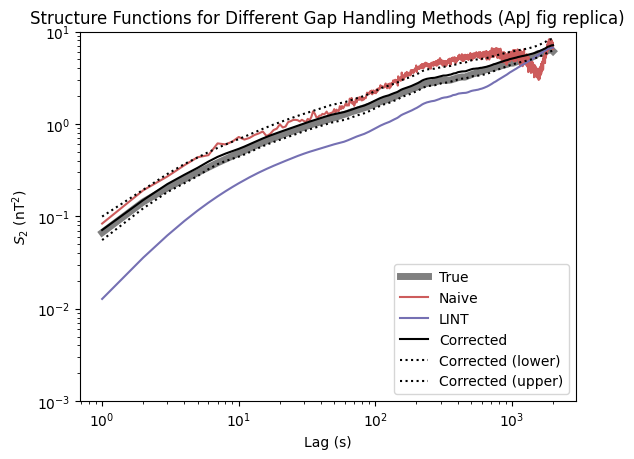

In [13]:
plt.loglog(sf_true_new["lag"], sf_true_new["sf"]*3, label="True", c=palette["true"], lw=5)
plt.loglog(sf_naive_new["lag"], sf_naive_new["sf"]*3, label="Naive", c=palette["naive"])
plt.loglog(sf_lint_new["lag"], sf_lint_new["sf"]*3, label="LINT", c=palette["lint"])
plt.loglog(sf_lint_new["lag"], sf_corr_new, label="Corrected", c=palette["corrected_3d"])
plt.loglog(
    sf_lint_new["lag"], sf_corr_lower, label="Corrected (lower)", c=palette["corrected_3d"], ls=":"
)
plt.loglog(
    sf_lint_new["lag"], sf_corr_upper, label="Corrected (upper)", c=palette["corrected_3d"], ls=":"
)
plt.xlabel("Lag (s)")
plt.ylabel(r"$S_2$ (nT$^2$)")
plt.ylim(1e-3, 1e1)
plt.title("Structure Functions for Different Gap Handling Methods (ApJ fig replica)")
plt.legend()
plt.show()